# Titanic Survival Prediction

#### Build a machine learning model that predicts whether a Titanic passenger survived based on passenger information.

In [1]:
# load the data
import pandas as pd

titanic = pd.read_csv('./Titanic-Dataset.csv')

titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# inspect 
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
# check class distribution
titanic['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [4]:
# normalize
titanic['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

## Exploratory Data Analysis

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Survived', ylabel='count'>

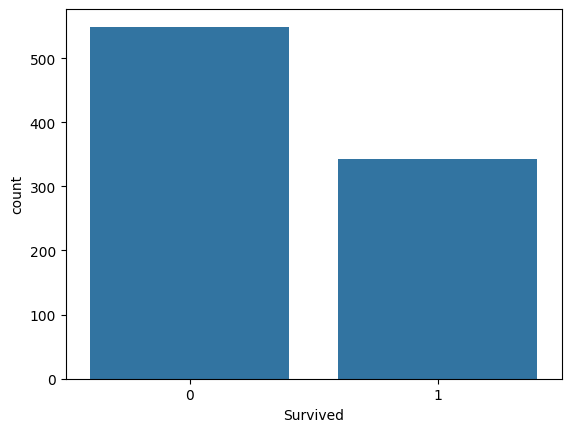

In [6]:
# target  variable
sns.countplot(data=titanic, x='Survived')

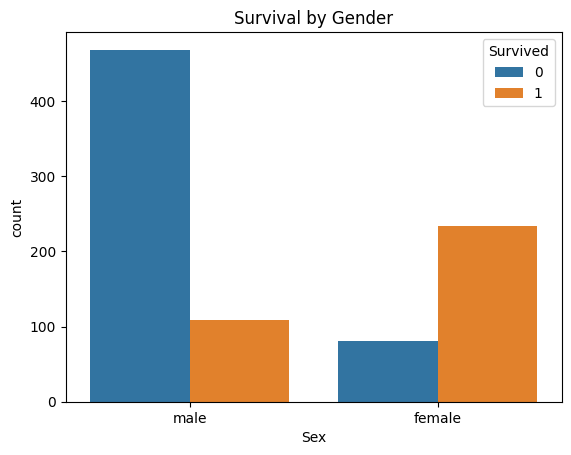

In [7]:
# Survival by gender
sns.countplot(data=titanic, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.show()

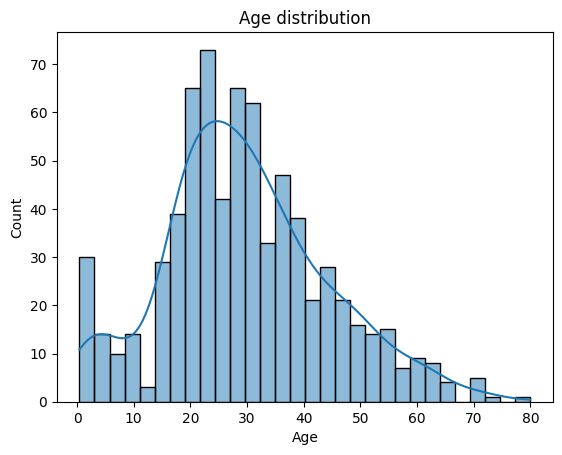

In [8]:
# Age distribution
sns.histplot(titanic["Age"], bins=30, kde=True)
plt.title("Age distribution")
plt.show()

Text(0.5, 1.0, 'Survived by Age')

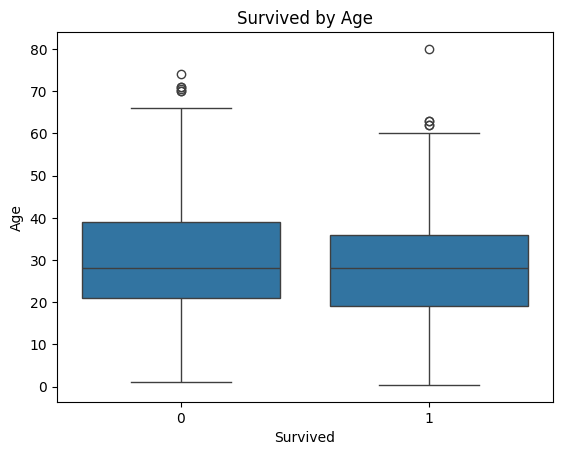

In [9]:
# survived by age
sns.boxplot(data=titanic, x="Survived", y="Age")
plt.title("Survived by Age")

Text(0.5, 1.0, 'Fare Distribution')

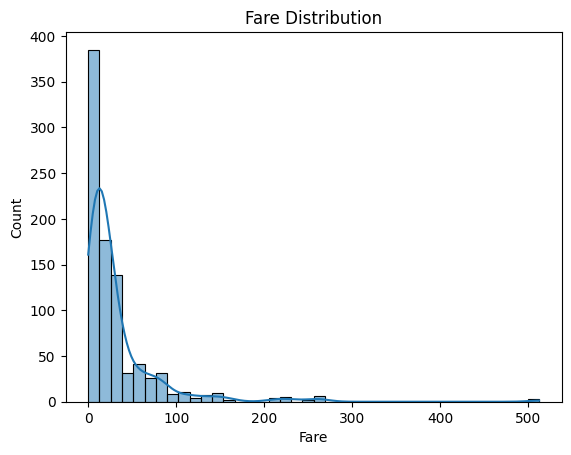

In [10]:
# Fare Distribution
sns.histplot(titanic["Fare"], bins=40, kde=True)
plt.title("Fare Distribution")

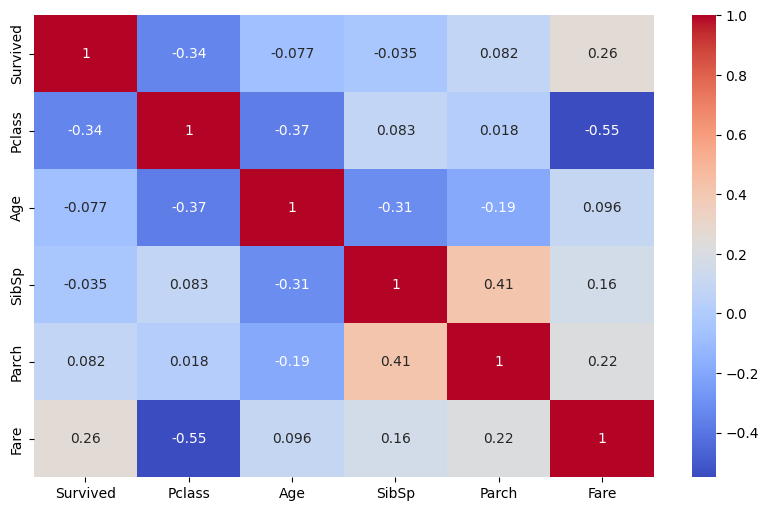

In [11]:
# correlation analysis
titanic = titanic.drop(columns=["PassengerId"])

corr = titanic.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("")
plt.show()

## Data Cleaning

In [12]:
# check missing  values
titanic.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [13]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    str    
 3   Sex       891 non-null    str    
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    str    
 8   Fare      891 non-null    float64
 9   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(4)
memory usage: 69.7 KB


In [13]:
# detect duplicates
titanic.duplicated().sum()

np.int64(0)

## Feature Engineering

In [14]:
print("Missing value percentage")
# print((f'{(titanic.isnull().mean()*100):.2f}'))
print((titanic.isnull().mean() *100).apply(lambda x: f"{x:.1f}%"))

Missing value percentage
Survived     0.0%
Pclass       0.0%
Name         0.0%
Sex          0.0%
Age         19.9%
SibSp        0.0%
Parch        0.0%
Ticket       0.0%
Fare         0.0%
Cabin       77.1%
Embarked     0.2%
dtype: str


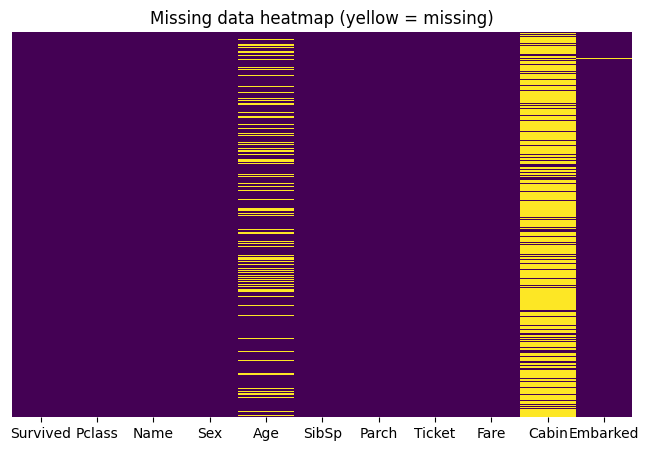

In [15]:
# plot missing data
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.heatmap(titanic.isnull(), cbar=False, cmap='viridis',yticklabels=False)
plt.title("Missing data heatmap (yellow = missing)")
plt.xlabel(" ")
plt.ylabel("")
plt.show()

In [16]:
# missing value (count vs percentage)
missing_df = pd.DataFrame({
    'missing_count': titanic.isnull().sum(),
    'missing_percentage': (titanic.isnull().mean() * 100).round(1)
})
missing_df

,missing_count,missing_percentage
Survived,0,0.0
Pclass,0,0.0
Name,0,0.0
Sex,0,0.0
Age,177,19.9
SibSp,0,0.0
Parch,0,0.0
Ticket,0,0.0
Fare,0,0.0
Cabin,687,77.1


In [17]:
# only missing value
print(missing_df[missing_df['missing_count'] > 0].sort_values(by='missing_percentage',ascending=False))

          missing_count  missing_percentage
Cabin               687                77.1
Age                 177                19.9
Embarked              2                 0.2


In [18]:
# simple imputation for age column
from sklearn.impute import SimpleImputer

age_imputer = SimpleImputer(strategy="median")

titanic['Age'] = age_imputer.fit_transform(titanic[['Age']])

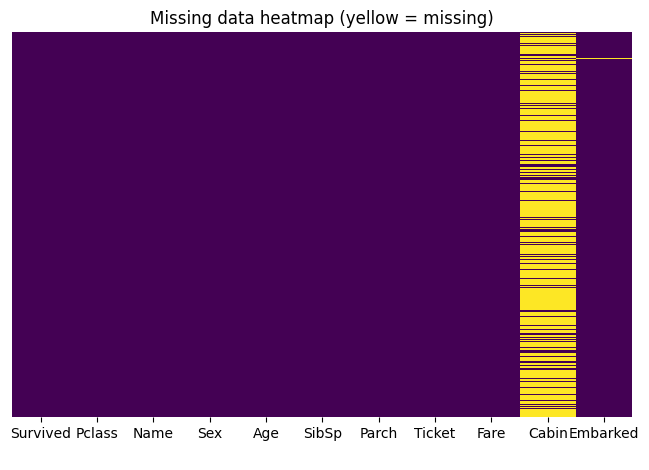

In [19]:
# plot missing data
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.heatmap(titanic.isnull(), cbar=False, cmap='viridis',yticklabels=False)
plt.title("Missing data heatmap (yellow = missing)")
plt.xlabel(" ")
plt.ylabel("")
plt.show()

In [20]:
# simple imputation for embarked column
from sklearn.impute import SimpleImputer

emb_imputer = SimpleImputer(strategy="most_frequent")

titanic['Embarked'] = emb_imputer.fit_transform(titanic[['Embarked']] ).ravel()

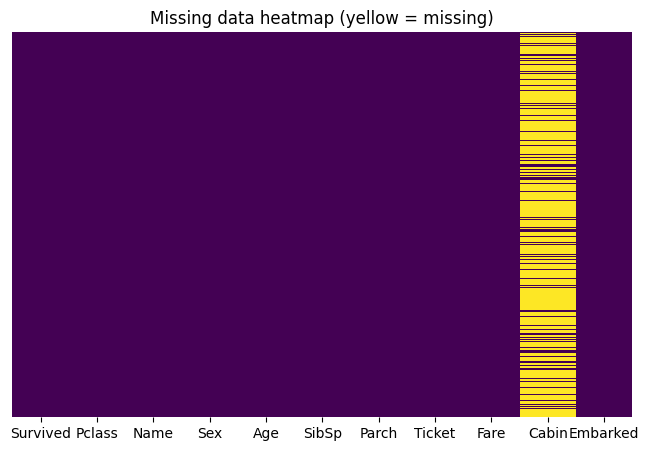

In [21]:
# plot missing data
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.heatmap(titanic.isnull(), cbar=False, cmap='viridis',yticklabels=False)
plt.title("Missing data heatmap (yellow = missing)")
plt.xlabel(" ")
plt.ylabel("")
plt.show()

In [22]:
# drop unneccesary columns
titanic = titanic.drop(columns=["Cabin","Name", "Ticket"])
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


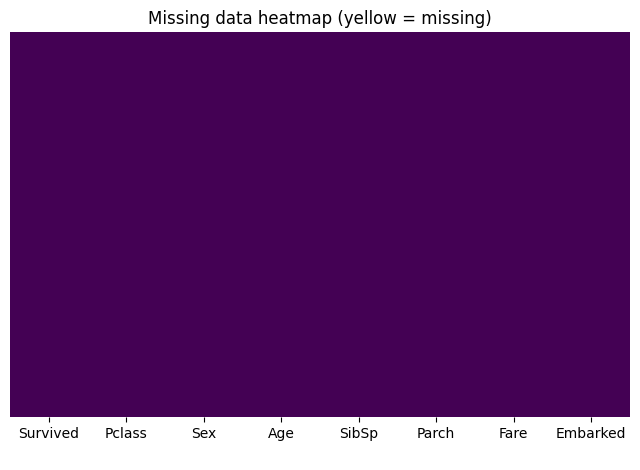

In [23]:
# plot missing data
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.heatmap(titanic.isnull(), cbar=False, cmap='viridis',yticklabels=False)
plt.title("Missing data heatmap (yellow = missing)")
plt.xlabel(" ")
plt.ylabel("")
plt.show()

In [24]:
# Encoding categorial data
titanic = pd.get_dummies(titanic, columns=["Sex", "Embarked"],drop_first=True, dtype=int)

## Train Model

In [25]:
# split training and testing data
from sklearn.model_selection import  train_test_split

X = titanic.drop("Survived", axis=1)

y = titanic["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


# scaling
from sklearn.preprocessing import StandardScaler

scaler =  StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
# train model 

from sklearn.linear_model import LogisticRegression

lmodel = LogisticRegression(max_iter=1000)

lmodel.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [27]:
# prediction
y_pred = lmodel.predict(X_test)

## Model Evaluation

In [48]:
# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")


Accuracy: 81.01%


In [57]:
# confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [54]:
# model overfitting?
print(f'Train score: {lmodel.score(X_train, y_train):.2%}')
print(f'Test score: {lmodel.score(X_test, y_test):.2%}')

Train score: 80.06%
Test score: 81.01%


In [56]:
# cross-validation
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(lmodel, X, y, cv=5)

scores = np.array(scores)

# Summary stats
mean_score = scores.mean()
min_score = scores.min()
max_score = scores.max()

print("Cross-Validation Results (5-Fold)\n")
print("Fold Accuracies:")
for i, score in enumerate(scores, 1):
    print(f"Fold {i}: {score:.3%}")

print("\nSummary:")
print(f"Mean Accuracy : {mean_score:.3%}")
print(f"Min Accuracy  : {min_score:.3%}")
print(f"Max Accuracy  : {max_score:.3%}")

print("\nFinal Result:")
print(f"Cross-validation Accuracy: {scores.mean():.3%}")

Cross-Validation Results (5-Fold)

Fold Accuracies:
Fold 1: 78.771%
Fold 2: 78.652%
Fold 3: 78.652%
Fold 4: 76.966%
Fold 5: 82.584%

Summary:
Mean Accuracy : 79.125%
Min Accuracy  : 76.966%
Max Accuracy  : 82.584%

Final Result:
Cross-validation Accuracy: 79.125%
